# L3 Analyse Numérique – TP3

<h1>Table des matières<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Approximation-par-splines-cubiques" data-toc-modified-id="Approximation-par-splines-cubiques-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Approximation par splines cubiques</a></span><ul class="toc-item"><li><span><a href="#Position-du-problème" data-toc-modified-id="Position-du-problème-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Position du problème</a></span></li><li><span><a href="#Reformulation-du-problème-et-premier-exemple" data-toc-modified-id="Reformulation-du-problème-et-premier-exemple-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Reformulation du problème et premier exemple</a></span></li><li><span><a href="#Quelques-observations-sur-les-splines-cubiques" data-toc-modified-id="Quelques-observations-sur-les-splines-cubiques-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Quelques observations sur les splines cubiques</a></span></li><li><span><a href="#Résolution-du-système-linéaire-par-&quot;boîte-noire&quot;" data-toc-modified-id="Résolution-du-système-linéaire-par-&quot;boîte-noire&quot;-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Résolution du système linéaire par "boîte noire"</a></span></li></ul></li><li><span><a href="#Méthodes-itératives" data-toc-modified-id="Méthodes-itératives-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Méthodes itératives</a></span><ul class="toc-item"><li><span><a href="#Mise-en-œuvre-des-méthodes-itératives-usuelles" data-toc-modified-id="Mise-en-œuvre-des-méthodes-itératives-usuelles-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Mise en œuvre des méthodes itératives usuelles</a></span></li><li><span><a href="#Résolution-des-splines-par-les-méthodes-itératives" data-toc-modified-id="Résolution-des-splines-par-les-méthodes-itératives-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Résolution des splines par les méthodes itératives</a></span></li><li><span><a href="#Paramètre-de-relaxation-optimal" data-toc-modified-id="Paramètre-de-relaxation-optimal-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Paramètre de relaxation optimal</a></span></li></ul></li></ul></div>

Charger au préalable les bibliothèques suivantes.

In [9]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import scipy

---
---

## Approximation par splines cubiques

### Position du problème

On considère une fonction donnée $u\in C^2([0,1],\mathbb{R})$ et un entier naturel $n$. On note alors $h=\tfrac{1}{n+1}$ et $x_i=ih$ pour $0\leq i\leq n+1$.  

*Définition*  
> Une spline cubique d'interpolation de la fonction $u$ en les points $(x_i)_{0\leq i \leq n+1}$ est une fonction $s_n$ vérifiant les propriétés suivantes:  
> a. $s_n(x_i)=u(x_i)$ pour tout $0\leq i \leq n+1$,  
> b. $s_n\in C^2([0,1],\mathbb{R})$,  
> c. $s_n''(0)=s_n''(1)=0$ (condition dite "naturelle")  
> d. $s_n$ est une fonction polynomiale de degré au plus 3 sur chaque intervalle $[x_i,x_{i+1}]$ pour $0\leq i \leq n$.
 
**Théorème**  
> **Il existe une unique spline cubique "naturelle" d'interpolation.**

*Mise en place du système linéaire à résoudre.*  
Au vu de la condition d, on recherche une fonction polynomiale par morceaux, de degré au plus 3 sur chacun des $n+1$ intervalles $[x_i,x_{i+1}]$, il y a donc $4(n+1)$ inconnues scalaires dans le problème. Les autres conditions (a. b. et c.) déterminent alors respectivement $2(n+1)$, $2n$ et $2$ équations, autrement dit un total de $4(n+1)$ équations linéaires scalaires. Nous admettrons que ces équations forment un système libre (donc inversible), ce qui démontre l'existence et l'unicité, pour tout entier naturel $n$, de la spline cubique $s_n$ satisfaisant aux propriétés précédentes. Le système d'équation admet une reformulation relativement allégée, en notant, sur chaque intervalle $[x_i,x_{i+1}]$, la spline $s_n$ sous la forme

$$ s_n(x) = \alpha_i + \beta_i (x-x_i) + \gamma_i (x-x_i)^2 + \delta_i (x-x_i)^3,\quad x\in[x_i,x_{i+1}], \ 0\leq i\leq n.$$

Après un travail des équations issues de (a. b. c. et d.), les inconnues $\alpha_i,\beta_i,\gamma_i$ et $\delta_i$ satisfont de _façon équivalente_ aux équations suivantes:

$$ \alpha_i = u(x_i),\qquad 0\leq i \leq n+1.  $$

$$ \delta_i = \dfrac{\gamma_{i+1}-\gamma_i}{3h},\qquad 0\leq i \leq n.  $$

$$ \beta_i = \dfrac{\alpha_{i+1}-\alpha_i}{h}-\dfrac{h}{3}(\gamma_{i+1}+2\gamma_i),\qquad 0\leq i \leq n. $$

$$ \gamma_{i+1}+4\gamma_i+\gamma_{i-1} = \dfrac{3}{h^2}(\alpha_{i+1}-2\alpha_i+\alpha_{i-1}),\qquad 1\leq i \leq n.$$

dans lesquelles on a posé $\gamma_{n+1}=\gamma_0=0$.



### Reformulation du problème et premier exemple

Le vecteur $G = (\gamma_i)_{1\leq i\leq n}$ est solution d'un système linéaire $AG = b$ de taille $n$ avec

$$ A =
\begin{pmatrix}
4 & 1 & & & \\
1 & 4 & \ddots & & \\
& \ddots & \ddots & \ddots \\
& & \ddots & 4 & 1 \\
& & & 1 & 4
\end{pmatrix},
\quad
b =
\dfrac{3}{h^2}
\begin{pmatrix}
\alpha_2-2\alpha_1+\alpha_0 \\
\alpha_3-2\alpha_2+\alpha_1 \\
\vdots \\
\alpha_{n} - 2\alpha_{n-1} + \alpha_{n-2} \\
\alpha_{n+1} - 2\alpha_n + \alpha_{n-1}
\end{pmatrix}.
$$

Les coefficients $(\beta_i)_{0\leq i \leq n}$ et $(\delta_i)_{0\leq i \leq n}$ sont ensuite obtenus directement à partir des équations précédentes, du vecteur $G = (\gamma_i)_{1\leq i\leq n}$ et des $(\alpha_i)_{0\leq i \leq n+1}$.  

La spline cubique d'interpolation peut être obtenue directement à travers la routine intégrée `scipy.interpolate.CubicSpline`, documentée dans l'aide. Vous êtes invités à la parcourir.  

Nous l'expérimentons ci-dessous sur un exemple inspiré de l'aide. Y sont calculées puis tracées: la fonction interpolée, la spline $s_n$ et ses dérivées successives $s_n',s_n'',s_n'''$. 

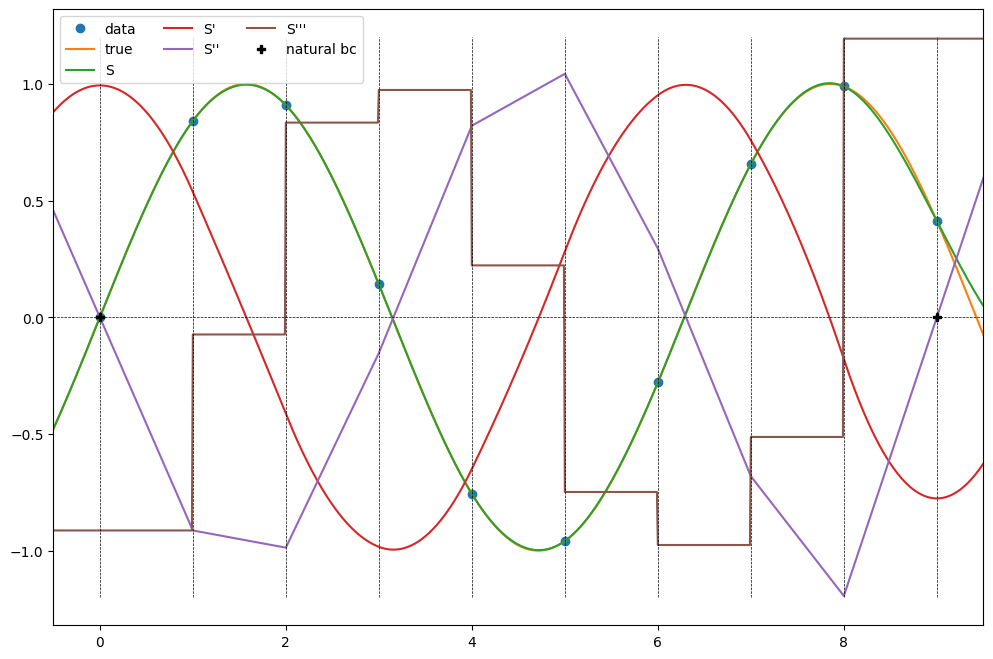

In [10]:
from scipy.interpolate import CubicSpline

x = np.arange(10)                         # Abscisses d'interpolation
y = np.sin(x)                             # Ordonnées d'interpolation
cs = CubicSpline(x, y, bc_type='natural') # Calcul de la Spline Cubique
# ATTENTION la fonction implémente différentes possibles conditions aux limites "bc_type"

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(x, y, 'o', label='data')          # Points d'interpolation
xs = np.arange(-0.5, 9.6, 0.01)           # Abscisses de tracé
ax.plot(xs, np.sin(xs), label='true')     # Tracer de la fonction interpolée
ax.plot(xs, cs(xs), label="S")            # Tracer de la Spline Cubique
ax.plot(xs, cs(xs, 1), label="S'")        # Tracer de sa dérivée
ax.plot(xs, cs(xs, 2), label="S''")       # Tracer de sa dérivée seconde
ax.plot(xs, cs(xs, 3), label="S'''")      # Tracer de sa dérivée troisième

# Condition de bord naturelle
ax.plot([x[0], x[-1]], [0, 0], 'Pk', label="natural bc")

for t in x:
    ax.plot([t, t], [-1.2, 1.2], '--k', linewidth=0.5)
ax.plot([-0.5, 9.5], [0, 0], '--k', linewidth=0.5)

ax.set_xlim(-0.5, 9.5)
ax.legend(loc='best', ncol=3)
plt.show()

Ce que renvoie la fonction `CubicSpline` (ici stocké dans la variable `cs`) n'est pas un objet usuel mais d'un type particulier. Sa classe est `scipy.interpolate.PPoly` et un extrait de la documentation renseigne alors les informations suivantes:

> **`class scipy.interpolate.PPoly(c, x, extrapolate=None, axis=0)`**  
> Piecewise polynomial in terms of coefficients and breakpoints
> 
> The polynomial between `x[i]` and `x[i + 1]` is written in the local power basis:
> 
> > `S = sum(c[m, i] * (xp - x[i])**(k-m) for m in range(k+1))`  
> where `k` is the degree of the polynomial.
> 
> **Parameters:**  
> `c`, ndarray, shape (k, m, …)  
> Polynomial coefficients, order k and m intervals.  
> 
> `x`, ndarray, shape (m+1,)  
> Polynomial breakpoints. Must be sorted in either increasing or decreasing order.

À l'aide de l'exemple précédent, on constate que l'on peut évaluer directement la spline `cs` et ses dérivées sur un vecteur d'abscisses `xs` par une syntaxe simple, par exemple `cs(xs,1)` détermine les valeurs de $s_n'$ en les points de `xs`.

In [11]:
print(cs.x)
print(cs.c)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[[-1.52272270e-01 -1.22831924e-02  1.39045722e-01  1.62359082e-01
   3.70637583e-02 -1.24784284e-01 -1.62663859e-01 -8.54840481e-02
   1.99019091e-01]
 [ 2.22044605e-16 -4.56816810e-01 -4.93666387e-01 -7.65292226e-02
   4.10548024e-01  5.21739299e-01  1.47386448e-01 -3.40605130e-01
  -5.97057274e-01]
 [ 9.93743255e-01  5.36926445e-01 -4.13556753e-01 -9.83752363e-01
  -6.49733562e-01  2.82553761e-01  9.51679508e-01  7.58460826e-01
  -1.79201578e-01]
 [ 0.00000000e+00  8.41470985e-01  9.09297427e-01  1.41120008e-01
  -7.56802495e-01 -9.58924275e-01 -2.79415498e-01  6.56986599e-01
   9.89358247e-01]]


À partir de l'objet `cs`, on peut identifier les coefficients $\alpha_i$, $\beta_i$, $\gamma_i$ et $\delta_i$.  
**Indication:** en Python, étant donné une variable `cs` dans la classe `PPoly`, on accède aux coefficients compris dans le ndarray `c` par `cs.c` et à `x` par `cs.x`.  

In [5]:
print(cs.x)
print(cs.c[3, :]) #coeffs à l'ordre 3 par intervale = coeffs delta_i
print(cs.c[2, :]) #coeffs à l'ordre 2 par intervale = coeffs gamma_i
print(cs.c[1, :]) #coeffs à l'ordre 1 par intervale = coeffs beta_i
print(cs.c[0, :]) #coeffs à l'ordre 0 par intervale = coeffs alpha_i
#visiblemetn non d'après indication qui suit

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427
 -0.2794155   0.6569866   0.98935825]
[ 0.99374325  0.53692644 -0.41355675 -0.98375236 -0.64973356  0.28255376
  0.95167951  0.75846083 -0.17920158]
[ 2.22044605e-16 -4.56816810e-01 -4.93666387e-01 -7.65292226e-02
  4.10548024e-01  5.21739299e-01  1.47386448e-01 -3.40605130e-01
 -5.97057274e-01]
[-0.15227227 -0.01228319  0.13904572  0.16235908  0.03706376 -0.12478428
 -0.16266386 -0.08548405  0.19901909]


Les coefficients de la matrice `cs.c` sont structurés de la façon suivante:
$$
cs.c = \begin{pmatrix}\delta_0 & \ldots & \delta_n \\
\gamma_0 & \ldots & \gamma_n\\
\beta_0 & \ldots & \beta_n\\
\alpha_0 & \ldots & \alpha_n\end{pmatrix},
$$
tandis que le vecteur `cs.x` est constitué comme suit:
$$
cs.x = \begin{pmatrix}x_0 & x_1 & \ldots & x_{n+1} \end{pmatrix}.
$$

### Quelques observations sur les splines cubiques

**Question 1.** Adapter le premier exemple afin de déterminer la spline cubique naturelle d'interpolation de la fonction $u(x) = \cos(10\pi x)$ sur l'intervalle $[0,1]$ en $14$ points équirépartis ($n=12$ points intérieurs). On représentera graphiquement la courbe de $u$, les points d'interpolation et la spline d'interpolation, ceci sur l'intervalle $[-0.1,1.1]$. On calculera et tracera également le polynôme d'interpolation de Lagrange en ces mêmes points.

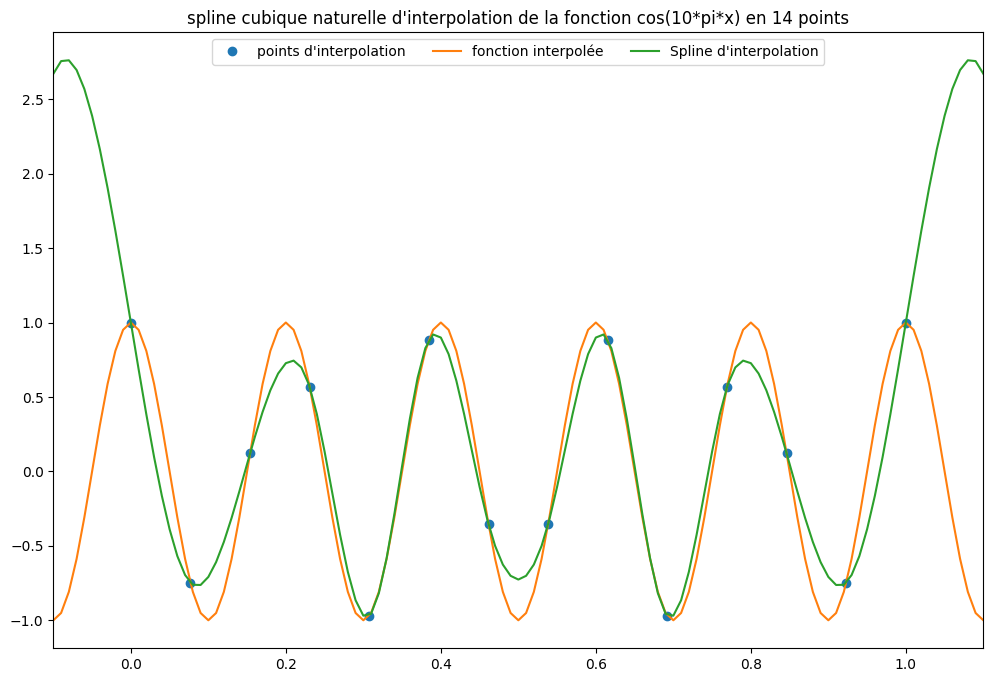

<Figure size 1200x800 with 0 Axes>

In [6]:
from scipy.interpolate import CubicSpline

x = np.arange(0,1+1/13,1/13)                        # Abscisses d'interpolation
y = np.cos(10*pi*x)                             # Ordonnées d'interpolation
cs = CubicSpline(x, y, bc_type='natural') # Calcul de la Spline Cubique
# ATTENTION la fonction implémente différentes possibles conditions aux limites "bc_type"

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(x, y, 'o', label="points d'interpolation")          # Points d'interpolation
xs = np.arange(-0.1, 1.1, 0.01)           # Abscisses de tracé
ax.plot(xs, np.cos(10*pi*xs), label='fonction interpolée')     # Tracer de la fonction interpolée
ax.plot(xs, cs(xs), label="Spline d'interpolation")            # Tracer de la Spline Cubique
#ax.plot(xs, cs(xs, 1), label="S'")        # Tracer de sa dérivée
#ax.plot(xs, cs(xs, 2), label="S''")       # Tracer de sa dérivée seconde
#ax.plot(xs, cs(xs, 3), label="S'''")      # Tracer de sa dérivée troisième

# Condition de bord naturelle
#ax.plot([x[0], x[-1]], [0, 0], 'Pk', label="natural bc")

#for t in x:
#    ax.plot([t, t], [-1, 2.75], '--k', linewidth=0.5)
#ax.plot([-1, 9.5], [0, 0], '--k', linewidth=0.5)
plt.figure(figsize=(12,8))
ax.set_xlim(-0.1, 1.1)
ax.set_title("spline cubique naturelle d'interpolation de la fonction cos(10*pi*x) en 14 points")

ax.legend(loc='best', ncol=3)
plt.show()

In [7]:


#def L(x,Xi,Yi):
#    L=0
#    for j,e in enumerate(Yi):
#        prod=1
#        for i,h in enumerate(Xi):
#            if i!=j:
#                prod*=(x-h)/(Xi[j]-h)
#        L+=e*prod
#    return L

#Xi = np.arange(0,1+1/13,1/13)     # Abscisses d'interpolation
#Yi = np.cos(10*pi*x)

#print(Xi,Yi)

#L=np.vectorize(L,excluded={'Xi','Yi'})
#xs = np.arange(-0.1, 1.1, 0.01)
#Ys=L(xs,Xi,Yi)

#ax.plot(xs,Ys)
#plt.show()

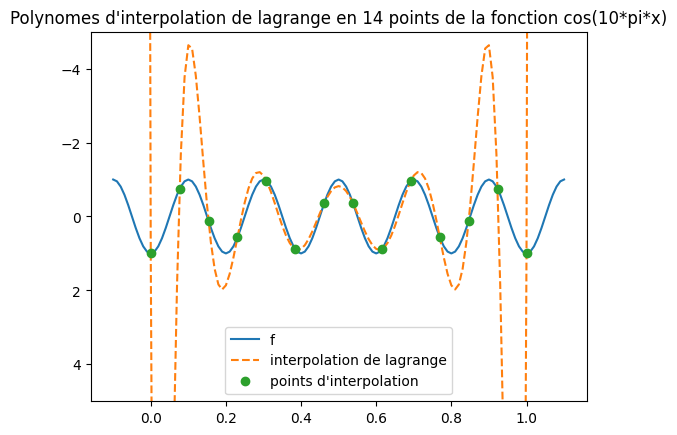

In [8]:
def f(x):
    y = cos(10*pi*x)
    return y
f=np.vectorize(f)

def diffdiv(x,y):
    n = len(x)
    D = np.zeros((n,n))
    D[:,0] = y
    for j in range (1,n):
        for i in range (n-j):
            D[i,j] = (D[i+1,j-1]-D[i,j-1])/(x[i+j]-x[i])
    return D


def fastexp(x,D,t):
    n = len(x)
    y = D[0,n-1]*np.ones(len(t))
    for k in range (n-2,-1,-1):
        y = (t-x[k])*y + D[0,k]
    return y


x = np.arange(-0.1, 1.1, 0.01)
y = f(x)
plt.plot(x,y, label = "f")


X = np.arange(0,1+1/13,1/13)
val  = f(X)
D = diffdiv(X,val)
yp = fastexp(X,D,x)
plt.plot(x,yp,'--',label = "interpolation de lagrange")
plt.title("Polynomes d'interpolation de lagrange en 14 points de la fonction cos(10*pi*x)")
plt.plot(X,val, 'o', label="points d'interpolation")
plt.ylim(5, -5)
plt.legend(loc="best")
plt.show()



**Question 2.**  Que se passe-t-il si on augmente le nombre de points $n$ pour la fonction $u(x) = \cos(10\pi x)$ ? Et pour la fonction $v(x) = (1+25(x-\tfrac12)^2)^{-1}$ ?

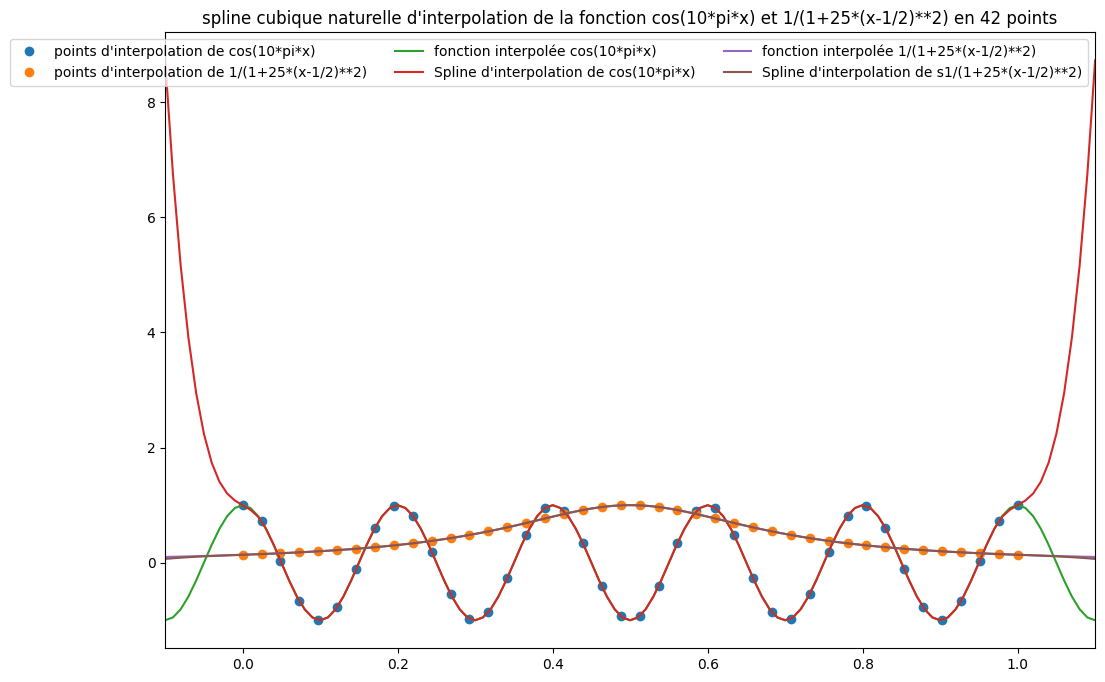

In [9]:
from scipy.interpolate import CubicSpline

n=40
def v(x):
    return 1/(1+25*(x-1/2)**2)
v=np.vectorize(v)

x = np.arange(0,1+1/(n+1),1/(n+1))                        # Abscisses d'interpolation
y = np.cos(10*pi*x)                             # Ordonnées d'interpolation
cs = CubicSpline(x, y, bc_type='natural') # Calcul de la Spline Cubique
# ATTENTION la fonction implémente différentes possibles conditions aux limites "bc_type"
y2 =v(x)
cs2 = CubicSpline(x, y2, bc_type='natural')

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(x, y, 'o', label="points d'interpolation de cos(10*pi*x)")          # Points d'interpolation
ax.plot(x, y2 ,'o', label="points d'interpolation de 1/(1+25*(x-1/2)**2)")
xs = np.arange(-0.1, 1.1, 0.01)           # Abscisses de tracé
ax.plot(xs, np.cos(10*pi*xs), label='fonction interpolée cos(10*pi*x)')     # Tracer de la fonction interpolée
ax.plot(xs, cs(xs), label="Spline d'interpolation de cos(10*pi*x)")            # Tracer de la Spline Cubique
ax.plot(xs, v(xs), label='fonction interpolée 1/(1+25*(x-1/2)**2)')     # Tracer de la fonction interpolée
ax.plot(xs, cs2(xs), label="Spline d'interpolation de s1/(1+25*(x-1/2)**2)")   
#ax.plot(xs, cs(xs, 1), label="S'")        # Tracer de sa dérivée
#ax.plot(xs, cs(xs, 2), label="S''")       # Tracer de sa dérivée seconde
#ax.plot(xs, cs(xs, 3), label="S'''")      # Tracer de sa dérivée troisième

# Condition de bord naturelle
#ax.plot([x[0], x[-1]], [0, 0], 'Pk', label="natural bc")

#for t in x:
#    ax.plot([t, t], [-1, 2.75], '--k', linewidth=0.5)
#ax.plot([-1, 9.5], [0, 0], '--k', linewidth=0.5)

ax.set_xlim(-0.1, 1.1)
ax.legend(loc='best', ncol=3)
ax.set_title("spline cubique naturelle d'interpolation de la fonction cos(10*pi*x) et 1/(1+25*(x-1/2)**2) en 42 points")
plt.show()

> **Mon commentaire**
> Le graphique me permet de me rendre compte qu'avec 42 pints d'inerpolations la spline cubique "colle" très bien à la fonction interpolée, j'ai aussi remarqué en changeant le nombre de point d'interpolations que pour la fonction v, à partir de 14 points, la spline cubique est déjà très proche de la fonction interpolée

### Résolution du système linéaire par "boîte noire"

Par nos propres moyens (ou preque), retrouvons une partie de la solution précédemment construite, à travers la résolution du système $AG=b$.

**Question 3.** Écrire une fonction `Spline` prenant en arguments la fonction $u$ et un entier $n$, et qui:
 - assemble la matrice $A$ et le vecteur $b$ du système précédent (à l'aide d'une stratégie de votre choix)
 - résoud $AG=b$ via `np.linalg.solve`
 - renvoie les vecteurs `x`, `y` et `G` avec:
     - `x` de longueur `n+2` contenant les valeurs de $x_i$ pour $0\leq i \leq n+1$,
     - `y` de longueur `n+2` contenant les valeurs de $u(x_i)$ pour $0\leq i \leq n+1$,
     - `G` de longueur `n` contenant les valeurs de $\gamma_i$ pour $1\leq i \leq n$.

In [18]:
def Spline(u,n):
    A=np.eye(n)*4+np.diag(np.ones(n-1)*1,1)+np.diag(np.ones(n-1)*1,-1)
    h=1/(n+1)
    x=np.array([i*h for i in range(0,n+2)])
    y=u(x)
    
    b=np.array([(3/(h**3))*(u(i*h)-2*u((i+1)*h)+u(h*(i+2))) for i in range(0,n)])
    #print (b,'cc')
    G=np.linalg.solve(A,b)
    
    #print(x,y)
    
    return x,y,G
#def f(x):
#print(Spline(f,10))
#h=1/(10+1)
#p##rint (np.array([i*h for i in range(0,n+2)]))

#for i in range(0,n):
#    h=1/(n+1)
#    print(i*h-2*((i+1)*h)+(h*(i+2)) )

**Question 4.** Tester la fonction précédente sur l'exemple utilisé dans la question 1.  
Valider le résultat obtenu en le comparant aux valeurs `G_Exacte` que renvoie `CubicSpline`.
```python
cs = CubicSpline(x, y, bc_type='natural')
G_Exacte = cs.c[1,1:]
```

In [19]:
x = np.arange(0,1+1/11,1/11)                           # Abscisses d'interpolation
y = np.sin(x)       
def f(x):
    return sin(x)
f=np.vectorize(f)
cs = CubicSpline(x, y, bc_type='natural')
G_Exacte = cs.c[1,1:]
x2,y2,G2=Spline(f,10)
print(G_Exacte,G2)

[-0.04542249 -0.09047431 -0.13476105 -0.17800184 -0.2195224  -0.26016359
 -0.2951718  -0.34074607 -0.33497526 -0.50755788] [-0.49964735 -0.99521737 -1.48237156 -1.95802025 -2.41474635 -2.86179954
 -3.24688979 -3.74820677 -3.68472791 -5.58313668]


---
---

## Méthodes itératives

Pour la suite du TP, nous implémentons les fonctions suivantes:
 - `Lower(L,b)` qui mène par la méthode de descente la résolution du système triangulaire inférieur $Lx=b$
 - `Upper(U,b)` qui mène par la méthode de remontée la résolution du système triangulaire supérieur $Ux=b$

In [15]:
def Lower(L, b):
    n = len(b)
    x = np.zeros(n)
    for i in range(n):
        x[i] = (b[i]-np.vdot(L[i, 0:i], x[0:i])) / L[i, i]
    return x


def Upper(U, b):
    n = len(b)
    x = np.zeros(n)
    for i in range(n):
        x[n-1-i] = (b[n-1-i]-np.vdot(U[n-1-i, n-i:n], x[n-i:n])) / \
            U[n-1-i, n-1-i]
    return x

<b>Quelques rappels du cours sur les méthodes itératives:</b>  

La matrice $A$ inversible est décomposée sous la forme $A=M-N$ avec $M$ facile et peu coûteuse à inverser. La solution $x$ est approchée par une suite $(x_k)_{k\in\mathbb{N}}$ d'éléments de $\mathbb{R}^n$:

$$\begin{array}{l} 
x_{0}\in \mathbb{R}^n \text{donné},\\
Mx_{k+1} = Nx_{k}+b.
\end{array}$$

La matrice $M^{-1}N$ est fondamentale dans l'analyse de convergence. En effet la solution $X$ de l'équation $AX=b$ est l'unique point fixe d'une application affine sur $\mathbb{R}^n$ dont la différentielle (constante) a pour matrice $M^{-1}N$. En particulier la convergence itérative de la méthode, requise pour tout choix de l'initialisation $x_0$, est équivalente à la condition suivante sur le rayon spectral:

 $$\rho(M^{-1}N)<1.$$

Quelques possibilités pour construire $M$ et $N$ : écrivons $A=D-E-F$ avec $D$ la partie diagonale de $A$, $-E$ sa partie triangulaire inférieure stricte et $-F$ sa partie triangulaire supérieure stricte. Autrement dit

$$
\begin{aligned}
&D_{ii}=A_{ii},\ i=1,\ldots,n,\\
&E_{ij}=-A_{ij},\ 1\leq j<i\leq n,\\
&F_{ij}=-A_{ij},\ 1\leq i<j\leq n,
\end{aligned}
$$

tous les autres termes étant nuls. Pour la construction de ces trois matrices utilisera la commande `np.diag`, ainsi que `np.triu` et `np.tril` (cf. documentation ou `help(...)`)

- Méthode de Jacobi : $M=D$ et $N=E+F$.
- Méthode de Gauss-Seidel : $M=D-E$ et $N=F$.
- Méthode de relaxation : $M=\frac 1\omega D-E$ et $N=\frac{1-\omega}\omega D+F$ avec $\omega\in\mathbb R^+_{*}$.


### Mise en œuvre des méthodes itératives usuelles

**Question 5.** Programmer les trois méthodes précedentes. On pourra mettre en place les itérations sur $k$ tant que $\|Ax_k-b\|_2$ est supérieur à une tolérance prescrite `eps` et que $k$ est inférieur à un nombre maximal `itmax` d'itérations. La résolution des systèmes triangulaires se fera exclusivement par un appel aux fonctions `Lower` et `Upper`.

In [2]:
# Méthode de Jacobi

def MJ(A):
    """Constitue les matrices M et N pour la méthode de Jacobi associée à A"""
    M = np.diag(np.diag(A))
    N = M - A
    return M, N


def Jacobi(A, b, x0, eps, itmax):
    """Effectue les itérations de la méthode de Jacobi pour résoudre Ax=b
    à partir de x0, sur au plus itmax itérations, avec une précision de eps"""
    x = x0
    M, N = MJ(A)
    # l'erreur initiale est ||Ax0 - b||
    err = np.linalg.norm(A.dot(x) - b)
    it = 0
    def summoi(A,x,i):
        s=0
        for j in range(len(x)+1):
            s+=A[i][j]*x[j]
        s-=A[i][i]*x[i]
        return s
    # on continue d'itérer tant qu'on n'a pas atteint la précision eps souhaitée ou dépassé le nombre d'itérations
    while err >= eps and it<itmax :        
        it=it+1
        err = np.linalg.norm(A.dot(x) - b)
        for i in range(1,n+1):
            x[i]=(b[i]-summoi(A,x,i))/a[i][i]
        
    # on renvoie le dernier itéré et le nombre d'itérations nécessaires
    return [x, it]

In [3]:
def MG(A):
    """Constitue les matrices M et N pour la méthode de Jacobi associée à A"""
    M = np.diag(A)-np.triu(A)
    N = np.tril(A)
    return M, N


def GaussSeidel(A, b, x0, eps, itmax):
    """Effectue les itérations de la méthode de Jacobi pour résoudre Ax=b
    à partir de x0, sur au plus itmax itérations, avec une précision de eps"""
    x = x0
    M, N = MG(A)
    # l'erreur initiale est ||Ax0 - b||
    err = np.linalg.norm(A.dot(x) - b)
    it = 0
    def sum1(A,y,i):
        s=0
        for j in range(len(y)+1):
            if j<i:
                s+=A[i][j]*y[j]
        return s
    def sum2(A,x,i):
        s=0
        for j in range(len(x)+1):
            if j>i:
                s+=A[i][j]*x[j]
        return s
    # on continue d'itérer tant qu'on n'a pas atteint la précision eps souhaitée ou dépassé le nombre d'itérations
    while err >= eps and it<itmax :        
        it=it+1
        err = np.linalg.norm(A.dot(x) - b)
        for i in range(1,n+1):
            x[i]=(b[i]-sum1(A,y,i)-sum2(A,x,i))/a[i][i]
        
    # on renvoie le dernier itéré et le nombre d'itérations nécessaires
    return [x, it]

In [5]:
def MR(A,w):
    """Constitue les matrices M et N pour la méthode de Jacobi associée à A"""
    M = (1/w)*np.diag(A)-np.triu(A)
    N = ((1-w)/w)*np.diag(A)+np.tril(A)
    return M, N


def relaxation(A, b, x0, eps, itmax):
    """Effectue les itérations de la méthode de Jacobi pour résoudre Ax=b
    à partir de x0, sur au plus itmax itérations, avec une précision de eps"""
    x = x0
    M, N = MR(A)
    # l'erreur initiale est ||Ax0 - b||
    err = np.linalg.norm(A.dot(x) - b)
    it = 0
    def sum11(A,x,i):
        s=0
        for j in range(0,i):
            s+=A[i][j]*x[j]
        s-=A[i][i]*x[i]
        return s
    def sum12(A,x,i):
        s=0
        for j in range(i+1,n+1):
            s+=A[i][j]*x[j]
        s-=A[i][i]*x[i]
        return s
    # on continue d'itérer tant qu'on n'a pas atteint la précision eps souhaitée ou dépassé le nombre d'itérations
    while err >= eps and it<itmax :        
        it=it+1
        err = np.linalg.norm(A.dot(x) - b)
        for i in range(1,n+1):
            x[i]=w*(b[i]-sum11(A,x,i)-sum12(A,x,i))/a[i][i]+(1-w)*x[i]
        
    # on renvoie le dernier itéré et le nombre d'itérations nécessaires
    return [x, it]

### Résolution des splines par les méthodes itératives

**Question 6.**  Utiliser les algorithmes précédents pour résoudre le système des Splines $AG=b$ avec $n=12$ (exemple de la question 1).  
On pourra choisir les paramètres suivants:
 - au maximum 200 itérations
 - tolérance sur le résidu: $10^{-9}$
 - $\omega = 1.07$ pour la relaxation  
 
On affichera pour chacune des méthodes le nombre d'itérations et la norme $\|x_K-G\|$ obtenu à l'issue des itérations.

In [13]:
""" La fonction suivante constitue le système linéaire des splines, permettant l'interpolation de la fonction u
 en n+2 points d'interpolations équirépartis dans [0,1]. Elle renvoie la matrice A et le second membre b,
 et accessoirement les vecteurs x et y. """


def u(x):
    return np.cos(10*pi*x)


def DataSplines(u, n):
    A = 4*np.diag(np.ones(n)) + np.diag(np.ones(n-1), 1) + \
        np.diag(np.ones(n-1), -1)
    A0 = -2*np.diag(np.ones(n+2)) + np.diag(np.ones(n+1), 1) + \
        np.diag(np.ones(n+1), -1)
    A0 = A0[1:n+1, :]
    x = np.linspace(0, 1, n+2)
    y = u(x)
    b = 3*(n+1)**2*A0.dot(y)
    return A, b, x, y

In [16]:
A, b, x, y= DataSplines(u,12)
print(GaussSeidel(A, b, x, 10**-9, 200))

A, b, x, y= DataSplines(u,12)
print(relaxation(A, b, x, 10**-9, 200))

ValueError: shapes (12,12) and (14,) not aligned: 12 (dim 1) != 14 (dim 0)

In [ ]:
A, b, x, y= DataSplines(u,12)
print(Jacobi(A, b, x, 10**-9, 200))

### Paramètre de relaxation optimal

**Question 7.**  Toujours pour $n=12$, représenter le rayon spectral de la matrice d'itération en fonction de $\omega$.
  
La théorie prévoit (pour une matrice $A$ tridiagonale) la valeur suivante:
$$ \omega_{\rm{optimal}} = \dfrac{1}{1+\sqrt{1-\rho(J)^2}},$$
où $J$ est la matrice d'itération de Jacobi.
L'application numérique de cette formule donne ici la valeur approchée $\omega_{\rm optimal} \simeq 1.0670919$.

Indiquer cette valeur optimale sur la figure.

**Fin du sujet**